In [23]:
# PHYS 311
# LAB 3 - OSCILLATOR SIMULATION
# Alexander Berry
# September 8, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt

## Part A - Simple Harmonic Oscillator

In this part, we simulate a simple harmonic oscillator using both the standard Euler and Euler-Cromer methods. Using a spring constant mass of (1.0), we are able to compare each numerical solution to the exact analytical solution while also tracking the total mechanical energy over time.

Natural frequency: 1.00 rad/s
Period: 6.28 s


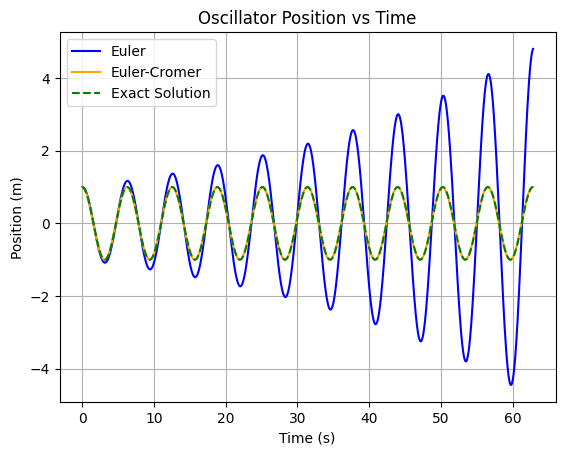

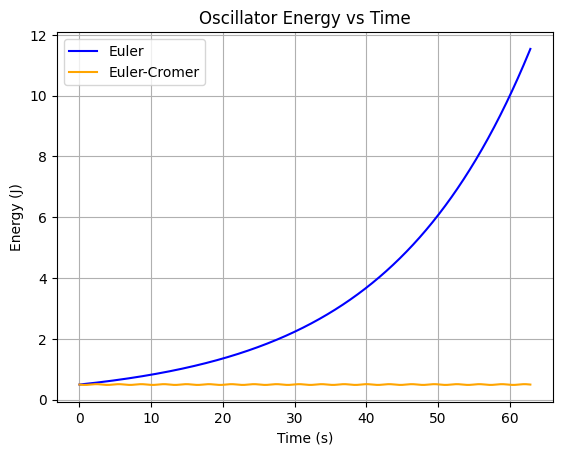

In [24]:
# PART A - SIMPLE HARMONIC OSCILLATOR

# A1. VALUES

k = 1.0
m = 1.0
x0 = 1.0
v0 = 0.0

omega0 = np.sqrt(k/m)
T = 2*np.pi/omega0

print(f"Natural frequency: {omega0:.2f} rad/s")
print(f"Period: {T:.2f} s")


# A2. SIMPLE HARMONIC OSCILLATOR FUNCTION

def simulate_oscillator(method, dt, n_periods=10):

    # Final simulation time
    t_final = n_periods * T

    # Starting position, velocity, and time
    x = x0
    v = v0
    t = 0.0

    # Starting total energy
    E_total = 0.5 * k * x**2 + 0.5 * m * v**2

    # Lists to store time, position, velocity, and energy
    t_list = [t]
    x_list = [x]
    v_list = [v]
    E_list = [E_total]

    # Calculate until the desired number of periods is reached
    while t < t_final:

        # Spring acceleration
        a = -k/m * x

        # Standard Euler method
        if method == 'euler':

            x_new = x + v * dt
            v_new = v + a * dt

            x = x_new
            v = v_new

        # Euler-Cromer method
        elif method == 'euler-cromer':

            v_new = v + a * dt
            x_new = x + v_new * dt

            x = x_new
            v = v_new

        else:
            raise ValueError("Method must be 'euler' or 'euler-cromer'.")

        # Update time
        t += dt

        # Recalculate total energy
        E_total = 0.5 * k * x**2 + 0.5 * m * v**2

        # Append new values to lists
        t_list.append(t)
        x_list.append(x)
        v_list.append(v)
        E_list.append(E_total)

    # Convert lists to numpy arrays for easier handling
    return (
        np.array(t_list),
        np.array(x_list),
        np.array(v_list),
        np.array(E_list)
    )


# A3. RUN BOTH METHODS

dt = 0.05

t_euler, x_euler, v_euler, E_euler = simulate_oscillator(
    'euler',
    dt
)

t_ec, x_ec, v_ec, E_ec = simulate_oscillator(
    'euler-cromer',
    dt
)


# A4. EXACT SOLUTION

x_exact = x0 * np.cos(omega0 * t_euler)


# A5. PLOT POSITION VS TIME

plt.figure()

plt.plot(
    t_euler,
    x_euler,
    label='Euler',
    color='blue'
)

plt.plot(
    t_ec,
    x_ec,
    label='Euler-Cromer',
    color='orange'
)

plt.plot(
    t_euler,
    x_exact,
    label='Exact Solution',
    color='green',
    linestyle='--'
)

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Oscillator Position vs Time')

plt.legend()
plt.grid()
plt.show()


# A6. PLOT ENERGY VS TIME

plt.figure()

plt.plot(
    t_euler,
    E_euler,
    label='Euler',
    color='blue'
)

plt.plot(
    t_ec,
    E_ec,
    label='Euler-Cromer',
    color='orange'
)

plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Oscillator Energy vs Time')

plt.legend()
plt.grid()
plt.show()


## Part A Interpretation

The standard Euler method produced an oscillator whose amplitude increased continously over time, even though the exact simple harmonic oscillator should have maintained a constant amplitude. This behavior is reflected in the energy plot where Euler continually adds nonphysical energy to the system itself. 

In comparison, the Euler-Cromer method closely follows the exact solutions and keeps the total energy bounded near its initial values!

Overall, this demonstration showed how the Euler-Cromer method is substantially more stable for oscillatory motion than the standard Euler method.

## Part B - Phase Space and Damped Oscillations

In this part, we use phase-space plots to further compare teh behavior of the Euler and Euler-Cromer methods. We then introduce a damping force to oscillator and ust the Euler-Cromer method to model underdamped, critically damped, and overdamped motion. 

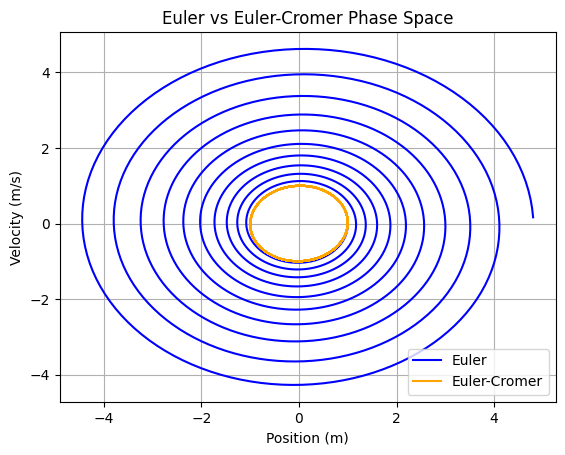

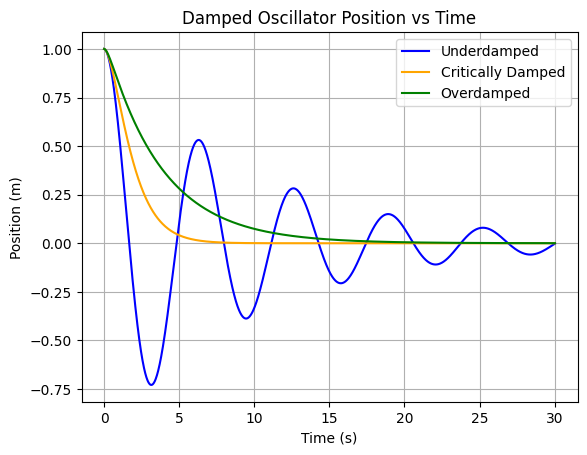

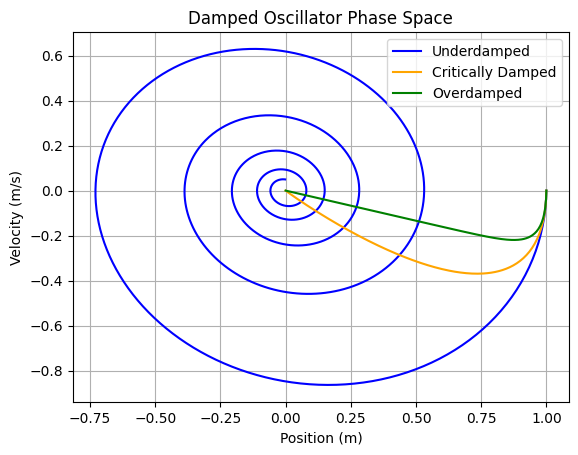

In [25]:
# PART B - PHASE SPACE AND DAMPED OSCILLATIONS

# B1. EULER VS EULER-CROMER PHASE SPACE

plt.figure()

plt.plot(
    x_euler,
    v_euler,
    label='Euler',
    color='blue'
)

plt.plot(
    x_ec,
    v_ec,
    label='Euler-Cromer',
    color='orange'
)

plt.xlabel('Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Euler vs Euler-Cromer Phase Space')

plt.legend()
plt.grid()
plt.show()


# B2. DAMPED OSCILLATOR FUNCTION

def simulate_damped_oscillator(b, dt=0.02, t_final=30.0):

    # Starting position, velocity, and time
    x = x0
    v = v0
    t = 0.0

    # Lists to store time, position, and velocity
    t_list = [t]
    x_list = [x]
    v_list = [v]

    # Calculate until the final simulation time is reached
    while t < t_final:

        # Spring and damping acceleration
        a = -k/m * x - b/m * v

        # Euler-Cromer method
        v_new = v + a * dt
        x_new = x + v_new * dt

        x = x_new
        v = v_new

        # Update time
        t += dt

        # Append new values to lists
        t_list.append(t)
        x_list.append(x)
        v_list.append(v)

    # Convert lists to numpy arrays for easier handling
    return (
        np.array(t_list),
        np.array(x_list),
        np.array(v_list)
    )


# B3. DAMPING VALUES

b_under = 0.2
b_critical = 2.0
b_over = 4.0

dt_damped = 0.02
t_final_damped = 30.0


# B4. RUN ALL THREE DAMPING REGIMES

t_under, x_under, v_under = simulate_damped_oscillator(
    b_under,
    dt_damped,
    t_final_damped
)

t_critical, x_critical, v_critical = simulate_damped_oscillator(
    b_critical,
    dt_damped,
    t_final_damped
)

t_over, x_over, v_over = simulate_damped_oscillator(
    b_over,
    dt_damped,
    t_final_damped
)


# B5. PLOT POSITION VS TIME

plt.figure()

plt.plot(
    t_under,
    x_under,
    label='Underdamped',
    color='blue'
)

plt.plot(
    t_critical,
    x_critical,
    label='Critically Damped',
    color='orange'
)

plt.plot(
    t_over,
    x_over,
    label='Overdamped',
    color='green'
)

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Damped Oscillator Position vs Time')

plt.legend()
plt.grid()
plt.show()


# B6. PLOT DAMPED PHASE SPACE

plt.figure()

plt.plot(
    x_under,
    v_under,
    label='Underdamped',
    color='blue'
)

plt.plot(
    x_critical,
    v_critical,
    label='Critically Damped',
    color='orange'
)

plt.plot(
    x_over,
    v_over,
    label='Overdamped',
    color='green'
)

plt.xlabel('Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Damped Oscillator Phase Space')

plt.legend()
plt.grid()
plt.show()

## Part B - Interpretation

The Euler phase-space plot spirals outward over time, which is consistent with the energy gain oberserved in Part A. Comparitively, the Euler-Cromer trajectory remained approximately closed, which shows that the oscillator's energy remains bounded.

When damping is introduced however, the underdamped oscillator continues to oscillalte while gradually decreasing in amplitude and spiraling inward toward equilibrium in phase space. The critically damped oscillator returns to equilibrium quickly without oscilating, whereas the overdamped oscillator also returns without oscillating (but much more slowly).

Overall, these results help demonstrate how increasing damping changes the system from oscillatory motion to a non-oscillatory return to equilibrium!

## Part C - Driven Oscillations and Resonance

In this part, we add a periodic driving force to the damped harmonic oscillator and use the Euler-Cromer method to model the resulting motion. 

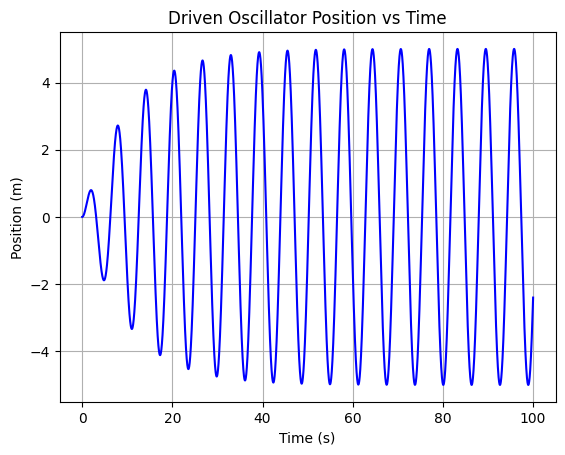

Natural frequency: 1.000 rad/s
Peak driving frequency: 0.993 rad/s
Maximum amplitude: 5.019 m


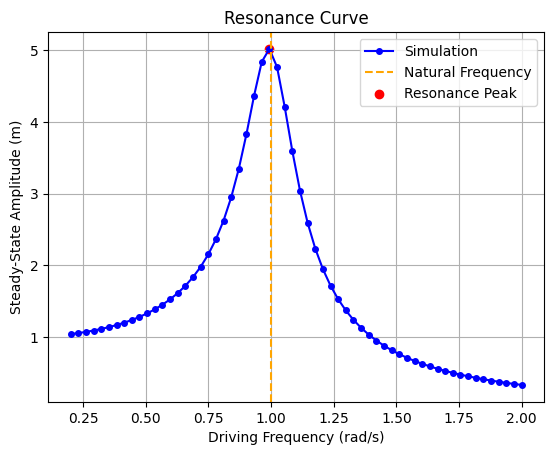

In [26]:
# PART C - DRIVEN OSCILLATIONS AND RESONANCE

# C1. VALUES

b = 0.2
F0 = 1.0

dt_driven = 0.02
t_final_driven = 100.0

omega_d = omega0


# C2. DRIVEN OSCILLATOR FUNCTION

def simulate_driven_oscillator(
    omega_d,
    b=0.2,
    F0=1.0,
    dt=0.02,
    t_final=100.0
):

    # Starting position, velocity, and time
    x = 0.0
    v = 0.0
    t = 0.0

    # Lists to store time, position, and velocity
    t_list = [t]
    x_list = [x]
    v_list = [v]

    # Calculate until the final simulation time is reached
    while t < t_final:

        # Spring, damping, and driving acceleration
        a = (
            -k/m * x
            - b/m * v
            + F0/m * np.cos(omega_d * t)
        )

        # Euler-Cromer method
        v_new = v + a * dt
        x_new = x + v_new * dt

        x = x_new
        v = v_new

        # Update time
        t += dt

        # Append new values to lists
        t_list.append(t)
        x_list.append(x)
        v_list.append(v)

    # Convert lists to numpy arrays for easier handling
    return (
        np.array(t_list),
        np.array(x_list),
        np.array(v_list)
    )


# C3. RUN AT NATURAL FREQUENCY

t_driven, x_driven, v_driven = simulate_driven_oscillator(
    omega_d,
    b,
    F0,
    dt_driven,
    t_final_driven
)


# C4. PLOT TRANSIENT TO STEADY STATE

plt.figure()

plt.plot(
    t_driven,
    x_driven,
    color='blue'
)

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Driven Oscillator Position vs Time')

plt.grid()
plt.show()


# C5. DRIVING FREQUENCY VALUES

omega_values = np.linspace(
    0.2,
    2.0,
    60
)

amplitude_list = []


# C6. FREQUENCY SWEEP

for omega_d in omega_values:

    # Run the oscillator long enough to reach steady state
    t_temp, x_temp, v_temp = simulate_driven_oscillator(
        omega_d,
        b,
        F0,
        dt=0.02,
        t_final=150.0
    )

    # Keep only the final 30 percent of the simulation
    n = len(x_temp)
    x_steady = x_temp[int(0.7 * n):]

    # Find the steady-state amplitude
    amplitude = np.max(np.abs(x_steady))

    # Save amplitude
    amplitude_list.append(amplitude)


# Convert amplitude list to numpy array
amplitude_values = np.array(amplitude_list)


# C7. FIND RESONANCE PEAK

peak_index = np.argmax(amplitude_values)

peak_omega = omega_values[peak_index]
peak_amplitude = amplitude_values[peak_index]

print(f"Natural frequency: {omega0:.3f} rad/s")
print(f"Peak driving frequency: {peak_omega:.3f} rad/s")
print(f"Maximum amplitude: {peak_amplitude:.3f} m")


# C8. PLOT RESONANCE CURVE

plt.figure()

plt.plot(
    omega_values,
    amplitude_values,
    color='blue',
    marker='o',
    markersize=4,
    label='Simulation'
)

plt.axvline(
    omega0,
    color='orange',
    linestyle='--',
    label='Natural Frequency'
)

plt.scatter(
    peak_omega,
    peak_amplitude,
    color='red',
    label='Resonance Peak'
)

plt.xlabel('Driving Frequency (rad/s)')
plt.ylabel('Steady-State Amplitude (m)')
plt.title('Resonance Curve')

plt.legend()
plt.grid()
plt.show()

## Part C - Interpretation

The driven oscillator initially experiences a transient response, but gradually strays away from it as the system settles into a steady oscillation determined by the driving force. When the driving frequency was varied, the largest steady-state amplitude occurred at approximately 0.993 rad/s, which is close to the natural frequency of 1.000 rad/s.

The maximum amplitude was approximately 5.019 m, which demonstrates the strong response that occurs near resonance. The difference between the peak driving force and the natural frequency is simply a result of damping. This is because it shifts the resonance peak slightly below the undamped natural frequency whilst limiting the maximum amplitude.

## Bonus - Nonlinear Pendulum

In this section, we simulate a nonlinear pendulum using the Euler-Cromer method. First comparing the measured period at a small angle of 5 degrees to the theoretical small-angle approximation. We then extrapolate the starting amplitude to determine when the small-angle approximation begins to break down. 

Small-angle period: 2.006 s

Measured period at 5 degrees: 2.007 s
Small-angle prediction: 2.006 s
Percent error: 0.048 %

Pendulum Period Results

5 degrees: 2.007 s
30 degrees: 2.041 s
90 degrees: 2.368 s
150 degrees: 3.535 s


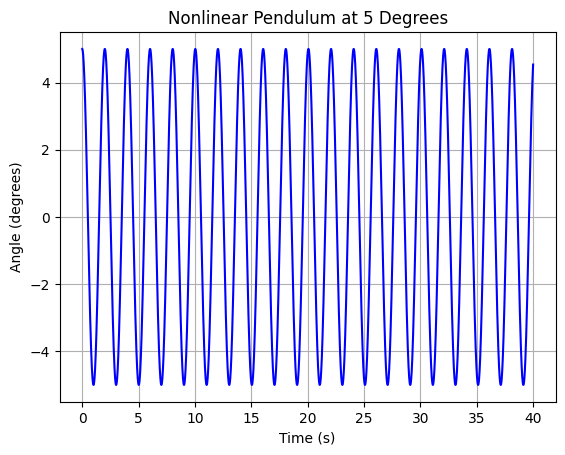

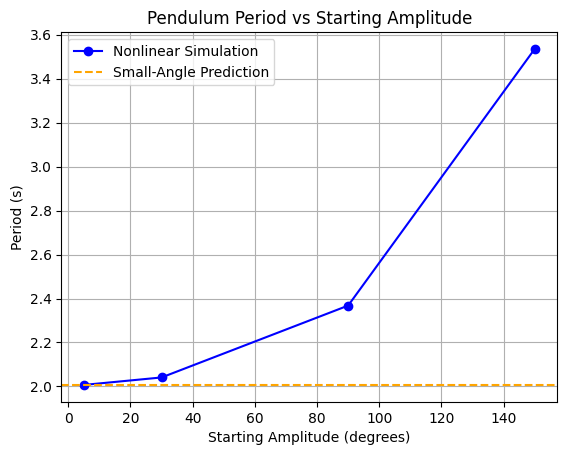

In [27]:
# BONUS - NONLINEAR PENDULUM

# BONUS 1. VALUES

g = 9.81
L = 1.0

dt_pendulum = 0.001
t_final_pendulum = 40.0

T_small_angle = 2*np.pi*np.sqrt(L/g)

print(f"Small-angle period: {T_small_angle:.3f} s")


# BONUS 2. NONLINEAR PENDULUM FUNCTION

def simulate_pendulum(theta0_deg, dt=0.001, t_final=40.0):

    # Convert starting angle to radians
    theta = np.radians(theta0_deg)

    # Starting angular velocity and time
    omega = 0.0
    t = 0.0

    # Lists to store time, angle, and angular velocity
    t_list = [t]
    theta_list = [theta]
    omega_list = [omega]

    # Calculate until the final simulation time is reached
    while t < t_final:

        # Pendulum angular acceleration
        alpha = -g/L * np.sin(theta)

        # Euler-Cromer method
        omega_new = omega + alpha * dt
        theta_new = theta + omega_new * dt

        theta = theta_new
        omega = omega_new

        # Update time
        t += dt

        # Append new values to lists
        t_list.append(t)
        theta_list.append(theta)
        omega_list.append(omega)

    # Convert lists to numpy arrays for easier handling
    return (
        np.array(t_list),
        np.array(theta_list),
        np.array(omega_list)
    )


# BONUS 3. PERIOD MEASUREMENT FUNCTION

def measure_period(t, theta):

    crossing_times = []

    # Find positive-to-negative zero crossings
    for i in range(len(theta) - 1):

        if theta[i] > 0 and theta[i + 1] <= 0:

            # Linear interpolation for a more accurate crossing time
            fraction = theta[i] / (theta[i] - theta[i + 1])

            crossing_time = (
                t[i]
                + fraction * (t[i + 1] - t[i])
            )

            crossing_times.append(crossing_time)

    # Convert to numpy array
    crossing_times = np.array(crossing_times)

    # Period is the time between equivalent zero crossings
    periods = np.diff(crossing_times)

    return np.mean(periods)


# BONUS 4. RUN SMALL-ANGLE CASE

t_5, theta_5, omega_5 = simulate_pendulum(
    5,
    dt_pendulum,
    t_final_pendulum
)

T_5 = measure_period(
    t_5,
    theta_5
)

percent_error = abs(
    T_5 - T_small_angle
) / T_small_angle * 100

print()
print(f"Measured period at 5 degrees: {T_5:.3f} s")
print(f"Small-angle prediction: {T_small_angle:.3f} s")
print(f"Percent error: {percent_error:.3f} %")


# BONUS 5. STARTING ANGLES

angle_values = np.array([
    5,
    30,
    90,
    150
])

period_values = []


# BONUS 6. MEASURE PERIOD AT EACH AMPLITUDE

for angle in angle_values:

    t_temp, theta_temp, omega_temp = simulate_pendulum(
        angle,
        dt_pendulum,
        t_final_pendulum
    )

    period = measure_period(
        t_temp,
        theta_temp
    )

    period_values.append(period)


# Convert period list to numpy array
period_values = np.array(period_values)


# BONUS 7. PRINT PERIOD RESULTS

print()
print("Pendulum Period Results")
print()

for i in range(len(angle_values)):

    print(
        f"{angle_values[i]} degrees: "
        f"{period_values[i]:.3f} s"
    )


# BONUS 8. PLOT ANGLE VS TIME

plt.figure()

plt.plot(
    t_5,
    np.degrees(theta_5),
    color='blue'
)

plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.title('Nonlinear Pendulum at 5 Degrees')

plt.grid()
plt.show()


# BONUS 9. PLOT PERIOD VS STARTING AMPLITUDE

plt.figure()

plt.plot(
    angle_values,
    period_values,
    color='blue',
    marker='o',
    label='Nonlinear Simulation'
)

plt.axhline(
    T_small_angle,
    color='orange',
    linestyle='--',
    label='Small-Angle Prediction'
)

plt.xlabel('Starting Amplitude (degrees)')
plt.ylabel('Period (s)')
plt.title('Pendulum Period vs Starting Amplitude')

plt.legend()
plt.grid()
plt.show()

## Bonus - Interpretation

At a starting angle of 5 degrees, the simulated period was approximatelyt 2.007 s, compared to the small-angle prediction of 2.006s. The resulting error was ony 0.048% which demonstrates that the small-angle approximation works extremely well at low amplitudes.

As the system's starting angle increased, the period also increased. The measured periods were approximately 2.041 s at 30 degrees, 2.368 s at 90, and 3.535 s at 150. This helps demonstrate how the small-angle approximation becomes increasingly inaccurate at large amplitudes because the nonlinear sinusodial behavior can no longer be approximated as simply theta. Overall, the simulation showed how a real nonlinear pendulum's period will depend on its starting amplitude, particularly at large angles.